In [31]:
import sounddevice as sd
import soundfile as sf

def record(filename="mic.wav", duration=4, sr=16000):
    print("Speak now...")
    rec = sd.rec(int(duration*sr), samplerate=sr, channels=1)
    sd.wait()
    sf.write(filename, rec, sr)
    print("Saved to", filename)

record("test_mic.wav", duration=4)


Speak now...
Saved to test_mic.wav


Sample rate: 16000 Samples: 64000


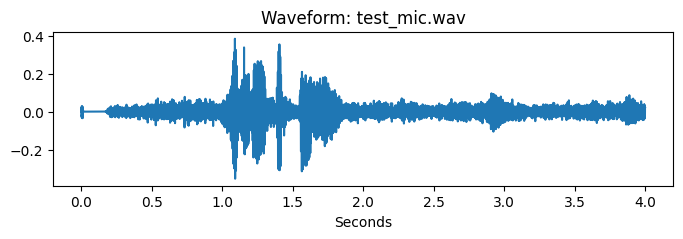

In [32]:
import librosa, soundfile as sf, numpy as np, matplotlib.pyplot as plt
from IPython.display import Audio, display

path = "test_mic.wav"
y, sr = librosa.load(path, sr=None)  # sr=None keeps original sample rate
print("Sample rate:", sr, "Samples:", len(y))
display(Audio(y, rate=sr))

# Plot waveform (short)
t = np.arange(len(y))/sr
plt.figure(figsize=(8,2))
plt.plot(t, y)
plt.title("Waveform: " + path)
plt.xlabel("Seconds")
plt.show()


In [33]:
import whisper

try:
    print("Loading Whisper model...")
    model = whisper.load_model("base")  # choose model: tiny, base, small, medium, large
    print("✅ Whisper model loaded successfully.")

except Exception as e:
    print(f"An unexpected error occurred while loading the Whisper model: {e}")


Loading Whisper model...
✅ Whisper model loaded successfully.


In [34]:
import os
import warnings

warnings.filterwarnings("ignore")

WAV_FILE = "test_mic.wav" 

try:
    if not os.path.exists(WAV_FILE):
        raise FileNotFoundError(f"WAV file '{WAV_FILE}' not found. Please check the path.")

    print("Recognizing... 🎤") 
    result = model.transcribe(WAV_FILE)

    whisper_transcript = result.get("text", "").strip()

    if whisper_transcript:
        print("🎤 Whisper transcript:", whisper_transcript)
        print("Speech successfully converted to text! ✅")
    else:
        print("Speech Recognition could not understand audio. Please try speaking more clearly.")

except FileNotFoundError as fnf_error:
    print(fnf_error)

except NameError as ne:
    print(f"NameError: {ne}. Make sure you have run the model-loading snippet (part1) in the same Python session so `model` exists.")

except Exception as e:
    print(f"An unexpected error occurred during transcription: {e}")


Recognizing... 🎤
🎤 Whisper transcript: Vishayakuthur kah mim
Speech successfully converted to text! ✅


In [35]:
import os, sys, zipfile, wave, json

MODEL_DIR = "vosk-model-small-en-us-0.15"
MODEL_ZIP = MODEL_DIR + ".zip"
MODEL_URL = "https://alphacephei.com/vosk/models/vosk-model-small-en-us-0.15.zip"

# 2) Download model if not present
if not os.path.isdir(MODEL_DIR):
    print("Model folder not found. Downloading model zip (50–60 MB)...")
    os.system(f"curl -L {MODEL_URL} -o {MODEL_ZIP}")
    print("Unzipping...")
    with zipfile.ZipFile(MODEL_ZIP, 'r') as z:
        z.extractall(".")
    os.remove(MODEL_ZIP)
    print("Unzipped.")


In [36]:
import os
from vosk import Model

try:
    # Load Vosk model
    model_path = os.path.abspath(MODEL_DIR)
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Vosk model directory '{MODEL_DIR}' not found.")
    
    print("Loading model from:", model_path)
    model = Model(model_path)
    print("✅ Model loaded successfully.")

except FileNotFoundError as fnf_error:
    print(fnf_error)

except Exception as e:
    print(f"An unexpected error occurred while loading the model: {e}")


Loading model from: /Users/abhijith/Christ/SPR/vosk-model-small-en-us-0.15
✅ Model loaded successfully.


LOG (VoskAPI:ReadDataFiles():model.cc:213) Decoding params beam=10 max-active=3000 lattice-beam=2
LOG (VoskAPI:ReadDataFiles():model.cc:216) Silence phones 1:2:3:4:5:6:7:8:9:10
LOG (VoskAPI:RemoveOrphanNodes():nnet-nnet.cc:948) Removed 0 orphan nodes.
LOG (VoskAPI:RemoveOrphanComponents():nnet-nnet.cc:847) Removing 0 orphan components.
LOG (VoskAPI:ReadDataFiles():model.cc:248) Loading i-vector extractor from /Users/abhijith/Christ/SPR/vosk-model-small-en-us-0.15/ivector/final.ie
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:183) Computing derived variables for iVector extractor
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:204) Done.
LOG (VoskAPI:ReadDataFiles():model.cc:282) Loading HCL and G from /Users/abhijith/Christ/SPR/vosk-model-small-en-us-0.15/graph/HCLr.fst /Users/abhijith/Christ/SPR/vosk-model-small-en-us-0.15/graph/Gr.fst
LOG (VoskAPI:ReadDataFiles():model.cc:303) Loading winfo /Users/abhijith/Christ/SPR/vosk-model-small-en-us-0.15/graph/phones/word_bound

In [37]:
import os
import wave
import json
from vosk import KaldiRecognizer

try:
    model_path = os.path.abspath(MODEL_DIR)
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Vosk model directory '{MODEL_DIR}' not found.")
    
    if not os.path.exists(WAV_FILE):
        print(f"⚠️ WAV file '{WAV_FILE}' not found. Upload it or change WAV_FILE variable.")
    else:
        wf = wave.open(WAV_FILE, "rb")
        rec = KaldiRecognizer(model, wf.getframerate())
        results = []
        print("Recognizing... 🎤")

        while True:
            data = wf.readframes(4000)
            if len(data) == 0:
                break
            if rec.AcceptWaveform(data):
                res = json.loads(rec.Result())
                text = res.get("text", "")
                if text:
                    results.append(text)

        final = json.loads(rec.FinalResult())
        if final.get("text", ""):
            results.append(final.get("text", ""))

        vosk_transcript = " ".join([r for r in results if r]).strip()
        
        if vosk_transcript:
            print("🎤 Vosk transcript:", vosk_transcript)
            print("Speech successfully converted to text! ✅")
        else:
            print("Speech Recognition could not understand audio. Please try speaking more clearly.")

except FileNotFoundError as fnf_error:
    print(fnf_error)

except NameError as ne:
    # Happens if `model` isn't defined because you didn't run snippet A in this session
    print(f"NameError: {ne}. Make sure you have run the model-loading snippet (part1) in the same Python session so `model` exists.")

except Exception as e:
    # Handles unexpected errors during transcription
    print(f"An unexpected error occurred during transcription: {e}")


Recognizing... 🎤
🎤 Vosk transcript: we say could tell you
Speech successfully converted to text! ✅


In [38]:
import speech_recognition as sr

recognizer = sr.Recognizer()

try:
    with sr.AudioFile(WAV_FILE) as source:
        print("Listening to audio file...")
        audio = recognizer.record(source)

    print("Recognizing...")
    google_transcript = recognizer.recognize_google(audio)
    print("🎤 Google Speech API transcript:", google_transcript)
    print("Speech successfully converted to text! ✅")

except sr.UnknownValueError:
    # Handles unclear speech (mumbling, low volume)
    print("Speech Recognition could not understand audio. Please try speaking more clearly.")

except sr.RequestError:
    # Handles service unavailability (internet/API down)
    print("Could not request results from Google Speech Recognition service. "
          "Please check your internet connection or try again later.")

except Exception as e:
    # Handles any other unexpected errors
    print(f"An unexpected error occurred: {e}")


Listening to audio file...
Recognizing...
🎤 Google Speech API transcript: Vishay could tell you
Speech successfully converted to text! ✅


In [39]:
# Compare Speech-to-Text Outputs

def compare_transcripts(whisper_text, vosk_text, google_text):
    print("\n======= SPEECH-TO-TEXT COMPARISON =======")
    print(f"Whisper: {whisper_text if whisper_text else '[No output]'}")
    print(f"Vosk:    {vosk_text if vosk_text else '[No output]'}")
    print(f"Google:  {google_text if google_text else '[No output]'}")
    print("=========================================")


compare_transcripts(
    whisper_text=whisper_transcript,       
    vosk_text=vosk_transcript,          
    google_text=google_transcript 
)



======= SPEECH-TO-TEXT COMPARISON =======
Whisper: Vishayakuthur kah mim
Vosk:    we say could tell you
Google:  Vishay could tell you



TF-IDF Cosine Similarity Matrix:
             GroundTruth  Whisper    Vosk  Google
GroundTruth       1.0000      0.0  0.4568  0.5500
Whisper           0.0000      1.0  0.0000  0.0000
Vosk              0.4568      0.0  1.0000  0.4568
Google            0.5500      0.0  0.4568  1.0000

Similarity of 'GroundTruth' vs systems:
  GroundTruth ↔ Whisper: 0.0000
  GroundTruth ↔ Vosk: 0.4568
  GroundTruth ↔ Google: 0.5500


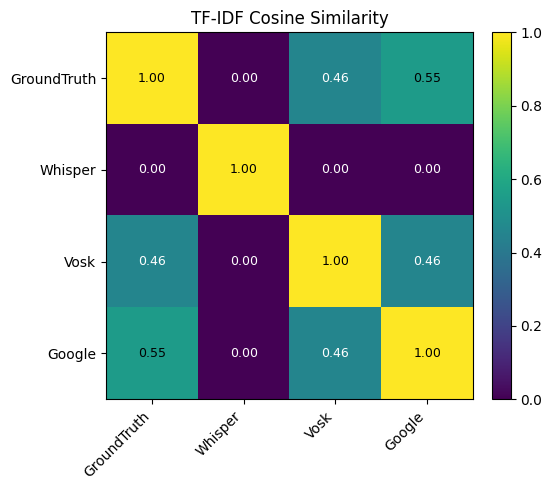

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def compute_tfidf_with_reference(transcripts, names=None, reference_text=None, ref_name="Reference", show_heatmap=True, cmap='viridis'):
  
    # Prepare names
    if names is None:
        names = [f"sys_{i}" for i in range(len(transcripts))]
    assert len(transcripts) == len(names), "transcripts and names must match lengths"

    # Build corpus
    corpus = []
    labels = []
    if reference_text is not None and reference_text.strip() != "":
        corpus.append(reference_text)
        labels.append(ref_name)

    for t, n in zip(transcripts, names):
        corpus.append(t if t is not None else "")
        labels.append(n)

    # TF-IDF vectorization
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus)

    # Cosine similarity
    sim_matrix = cosine_similarity(X)

    # DataFrame
    df = pd.DataFrame(sim_matrix, index=labels, columns=labels)

    print("\nTF-IDF Cosine Similarity Matrix:")
    print(df.round(4))

    if reference_text is not None and reference_text.strip() != "":
        print(f"\nSimilarity of '{ref_name}' vs systems:")
        ref_sims = sim_matrix[0, 1:]
        for label, val in zip(labels[1:], ref_sims):
            print(f"  {ref_name} ↔ {label}: {val:.4f}")

    # Heatmap
    if show_heatmap:
        plt.figure(figsize=(6,5))
        im = plt.imshow(sim_matrix, vmin=0.0, vmax=1.0, cmap=cmap)
        plt.title("TF-IDF Cosine Similarity")
        plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
        plt.yticks(range(len(labels)), labels)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        for i in range(sim_matrix.shape[0]):
            for j in range(sim_matrix.shape[1]):
                plt.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                         fontsize=9, color='white' if sim_matrix[i,j] < 0.5 else 'black')
        plt.tight_layout()
        plt.show()

    return sim_matrix, df


# Ask user for reference at runtime
reference_text = input("👉 Enter the exact ground-truth/reference text: ")

sim_matrix, sim_df = compute_tfidf_with_reference(
    transcripts=[whisper_transcript, vosk_transcript, google_transcript],
    names=["Whisper","Vosk","Google"],
    reference_text=reference_text,
    ref_name="GroundTruth",
    show_heatmap=True
)
